# 01 — Building the child-level analysis table
Links the three GSPS waves into one row per child. Population: children aged 8–13 enrolled in school at Wave 1 (2009/10); outcome observed at Wave 2 (2013/14).

## 1. Wave 1 children aged 8–13
Loads the Wave 1 roster (`s1d`) and household information (`key_hhld_info`: region, district, EA, urban/rural, survey weight).

In [1]:
import pyreadstat
import pandas as pd
import numpy as np
from pathlib import Path
import os

ROOT = Path(os.getcwd())
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
RAW = ROOT / "data" / "raw" / "Ghana_Panel_Survey" / "Data"

def load(wave, file):
    """Read one GSPS .dta file; fall back to latin1 for legacy-encoded files."""
    path = RAW / f"Wave {wave}" / file
    try:
        return pyreadstat.read_dta(path)
    except UnicodeDecodeError:
        return pyreadstat.read_dta(path, encoding="latin1")

def num(s):
    """Many GSPS numeric columns are stored as text: convert, non-numbers -> NaN."""
    return pd.to_numeric(s, errors="coerce")

print("Setup OK")

Setup OK


## 2. Wave 1 education, keeping enrolled children
Adds the Wave 1 education module (`s1fi`) and keeps children reported as still in school. Data issues: 2 duplicate rows; 425 children with no answer to "still in school" (280 never attended).

In [2]:
r1, m_r1 = load(1, "s1d.dta")              # Wave 1 household roster
hh1, _  = load(1, "key_hhld_info.dta")     # Wave 1 region, district, EA, urban/rural, weights

w1 = pd.DataFrame({
    "FPrimary": r1["FPrimary"].astype(str),   # household ID (stored as number in W1, text in W2/W3)
    "hhmid":    num(r1["hhmid"]),             # member ID within household
    "sex":      num(r1["s1d_1"]),             # 1 = male, 2 = female
    "age":      num(r1["s1d_4i"]),            # age in years
})

hh1 = hh1.assign(FPrimary=hh1["FPrimary"].astype(str))[
    ["FPrimary", "regioncode", "districtcode", "eacode", "urbrur", "hhweight3"]]
w1 = w1.merge(hh1, on="FPrimary", how="left")

kids1 = w1[w1["age"].between(8, 13)].copy()
print("All Wave 1 members:", len(w1))
print("Children aged 8-13:", len(kids1))
print("Children with no household info:", kids1["regioncode"].isna().sum())

All Wave 1 members: 18889
Children aged 8-13: 3024
Children with no household info: 0


## 3. Link to Wave 2
Attaches each child's Wave 2 roster, education and pre-roster record (the pre-roster gives reasons for leaving the household).

In [3]:
e1, m_e1 = load(1, "s1fi.dta")                       # Wave 1 education module
e1 = e1.rename(columns={"s1fi_hhmid": "hhmid"})       # member ID has a different name here
e1["FPrimary"] = e1["FPrimary"].astype(str)
e1["hhmid"] = num(e1["hhmid"])

print("Duplicate person rows in education file:", e1.duplicated(["FPrimary", "hhmid"]).sum())
e1 = e1.drop_duplicates(["FPrimary", "hhmid"], keep="first")

edu_cols = {
    "s1fi_6":   "in_school",            # 1 = yes, 2 = no
    "s1fi_7":   "school_type",          # public / private
    "s1fi_8":   "current_grade",        # grade code (11-16 = P1-P6, 17-19 = JSS1-3)
    "s1fi_9i":  "travel_hrs",  "s1fi_9ii":  "travel_min",
    "s1fi_10i": "attend_hrs",  "s1fi_10ii": "attend_min",
    "s1fi_11i": "missed_hrs",  "s1fi_11ii": "missed_min",
    "s1fi_34":  "teacher_absent_days",
    "s1fi_21i": "school_spend_total",
    "s1fi_25":  "has_textbooks",
    "s1fi_27":  "feeding_program",
}
e1_small = e1[["FPrimary", "hhmid"] + list(edu_cols)].rename(columns=edu_cols)
for c in edu_cols.values():
    e1_small[c] = num(e1_small[c])

kids1 = kids1.merge(e1_small, on=["FPrimary", "hhmid"], how="left")
print("Children aged 8-13:", len(kids1))
print("in_school values:", kids1["in_school"].value_counts(dropna=False).to_dict())

base = kids1[kids1["in_school"] == 1].copy()
print("Enrolled children aged 8-13 (Wave 1 baseline):", len(base))

Duplicate person rows in education file: 2
Children aged 8-13: 3024
in_school values: {1.0: 2532, nan: 425, 2.0: 67}
Enrolled children aged 8-13 (Wave 1 baseline): 2532


In [4]:
# --- Wave 2 roster, education and pre-roster (attrition reasons) ---
r2, _   = load(2, "01b2_roster.dta")
e2, _   = load(2, "01fi_generaleducation.dta")
pre2, m_pre2 = load(2, "01b2_preroster.dta")
for d in (r2, e2, pre2):
    d["FPrimary"] = d["FPrimary"].astype(str).str.strip()

w2 = r2[["FPrimary", "hhmid", "gender", "ageyears"]].merge(
    e2[["FPrimary", "hhmid", "attendedlast12", "attendingstill", "highestgrade"]],
    on=["FPrimary", "hhmid"], how="left")
w2 = w2.rename(columns={"gender": "sex_w2", "ageyears": "age_w2",
                        "attendedlast12": "attended12_w2", "attendingstill": "in_school_w2",
                        "highestgrade": "highest_grade_w2"})
for c in ["sex_w2", "age_w2", "attended12_w2", "in_school_w2", "highest_grade_w2"]:
    w2[c] = num(w2[c])

# The W2 pre-roster lists Wave 1 members; its InstanceNumber = their Wave 1 member ID
pre2 = pre2.drop(columns="hhmid").rename(columns={"InstanceNumber": "hhmid"})[
    ["FPrimary", "hhmid", "stillmembercollect", "whynotmember"]]
pre2["stillmembercollect"] = num(pre2["stillmembercollect"])
pre2["whynotmember"] = num(pre2["whynotmember"])

base = base.merge(w2, on=["FPrimary", "hhmid"], how="left").merge(pre2, on=["FPrimary", "hhmid"], how="left")
print("Rows:", len(base))

Rows: 2532


## 4. Outcome status at Wave 2 (the label)
Checks that the Wave 2 person is the same child (sex matches, age +2 to +7 years) and assigns a status. Model uses only `enrolled` (Y = 0) and `dropout` (Y = 1).

In [5]:
# --- Is the Wave 2 person really the same child? (sex must match; age must rise by 2-7 years) ---
found      = base["age_w2"].notna()
same_sex   = ((base["sex"] == 1) & (base["sex_w2"] == 1)) | ((base["sex"] == 2) & (base["sex_w2"] == 5))
age_ok     = (base["age_w2"] - base["age"]).between(2, 7)
consistent = found & same_sex & age_ok

left_school = (base["in_school_w2"] == 5) | (base["attended12_w2"] == 5)
completed   = base["highest_grade_w2"].between(19, 31)   # JSS3 or higher = finished basic education

base["status"] = np.select(
    [consistent & (base["in_school_w2"] == 1),
     consistent & left_school & completed,
     consistent & left_school & ~completed,
     consistent,
     found & ~consistent,
     base["stillmembercollect"] == 5,
     base["FPrimary"].isin(set(r2["FPrimary"]))],
    ["enrolled", "completed_basic", "dropout", "status_unknown",
     "id_mismatch", "moved_out", "not_in_w2_roster"],
    default="household_not_found")

print(base["status"].value_counts().to_string())

status
enrolled               1119
moved_out               640
household_not_found     303
dropout                 188
id_mismatch             164
completed_basic          67
not_in_w2_roster         30
status_unknown           21


## 5. School and attendance features (Wave 1)
Recodes code 99 ("on vacation") to missing, combines hours + minutes, derives grade level, over-age for grade and total school spending.

In [6]:
# --- Wave 1 school & attendance features ---
SENTINEL_99 = 99   # questionnaire: "If on vacation, code 99 for HOURS"
base["on_vacation"] = ((base["attend_hrs"] == 99) | (base["missed_hrs"] == 99)).astype(int)
for c in ["attend_hrs", "attend_min", "missed_hrs", "missed_min", "travel_hrs", "travel_min"]:
    base.loc[base[c] == SENTINEL_99, c] = np.nan

def hours_plus_minutes(h, m):
    """Combine an hours box and a minutes box; a blank box counts as 0 only if the other box is filled."""
    any_filled = h.notna() | m.notna()
    return (h.fillna(0) + m.fillna(0) / 60).where(any_filled)

base["attend_hours"]   = hours_plus_minutes(base["attend_hrs"], base["attend_min"])
base["missed_hours"]   = hours_plus_minutes(base["missed_hrs"], base["missed_min"])
base["travel_minutes"] = hours_plus_minutes(base["travel_hrs"], base["travel_min"]) * 60

base.loc[base["teacher_absent_days"] < 0, "teacher_absent_days"] = np.nan   # -8 = not applicable code

# Grade -> position in school (P1 = 1 ... JSS3 = 9, preschool = 0); other codes are invalid for ages 8-13
grade_map = {1: 0, 11: 1, 12: 2, 13: 3, 14: 4, 15: 5, 16: 6, 17: 7, 18: 8, 19: 9}
base["grade_level"] = base["current_grade"].map(grade_map)
base["over_age"] = base["age"] - (base["grade_level"] + 5)   # official entry: P1 at age 6

# School spending in the last 12 months (cedis): the questionnaire asks 8 itemised amounts (Q13-Q20,
# cedis + pesewas) and asks a single total (Q21) only when the respondent cannot itemise.
spend = e1[["FPrimary", "hhmid"]].copy()
item_cols = []
for q in range(13, 21):
    cedis, pesewas = num(e1[f"s1fi_{q}i"]), num(e1[f"s1fi_{q}ii"])
    spend[f"item{q}"] = (cedis.fillna(0) + pesewas.fillna(0) / 100).where(cedis.notna() | pesewas.notna())
    item_cols.append(f"item{q}")
spend["itemised"] = spend[item_cols].sum(axis=1, min_count=1)
base = base.merge(spend[["FPrimary", "hhmid", "itemised"]], on=["FPrimary", "hhmid"], how="left")
base["school_spend"] = base["itemised"].fillna(base["school_spend_total"])
base = base.drop(columns=["itemised", "school_spend_total"])

print("On vacation (99 code):", base["on_vacation"].sum())
print(base[["attend_hours", "missed_hours", "travel_minutes", "teacher_absent_days",
            "school_spend", "grade_level", "over_age"]].describe().round(1).T[["count", "mean", "50%", "max"]])

On vacation (99 code): 183
                      count   mean   50%     max
attend_hours         1964.0   27.2  30.0    80.0
missed_hours          522.0    7.2   3.0    64.0
travel_minutes       2463.0   80.7  20.0  2735.0
teacher_absent_days  1034.0    0.9   0.0    24.0
school_spend         2493.0  146.9  83.0  6500.0
grade_level          2369.0    3.6   3.0     9.0
over_age             2369.0    1.8   2.0     7.0


## 6. Math and English test scores (Wave 1)
Scores letter answers with the recovered answer key (math 8 items, English 7 items). Records whether each child was scored, left a blank sheet, or was not tested.

In [7]:
# --- Wave 1 math and English tests (answers stored as letters A-D) ---
# Answer key derived from Wave 3 (which records right/wrong) and confirmed as the most common
# answer to every item in Waves 1 and 2.
MATH_KEY    = {f"s9d_{i}": k for i, k in zip(range(1, 9),  "DCBCDBBC")}   # Q1-Q8
ENGLISH_KEY = {f"s9e_{i}": k for i, k in zip(range(9, 16), "BADCCBD")}    # Q9-Q15 (Q16 only exists in Wave 1 -> dropped)

def score_test(df, id_col, key):
    out = df[["FPrimary"]].astype(str).copy()
    out["hhmid"] = num(df[id_col])
    answers = df[list(key)].apply(lambda s: s.astype(str).str.strip().str.upper())
    answered = answers.isin(["A", "B", "C", "D"])
    correct = pd.DataFrame({c: answers[c] == k for c, k in key.items()})
    out["score"] = correct.sum(axis=1).where(answered.any(axis=1))   # blank answer sheet -> no score
    out["status"] = np.where(answered.any(axis=1), "scored", "blank_sheet")
    out = out.dropna(subset=["hhmid"]).drop_duplicates(["FPrimary", "hhmid"])
    return out

m1, _ = load(1, "s9d.dta")
en1, _ = load(1, "s9e.dta")
math1 = score_test(m1, "s9d_id", MATH_KEY).rename(columns={"score": "math_score", "status": "math_status"})
eng1  = score_test(en1, "s9d_ie", ENGLISH_KEY).rename(columns={"score": "english_score", "status": "english_status"})

base = base.merge(math1, on=["FPrimary", "hhmid"], how="left").merge(eng1, on=["FPrimary", "hhmid"], how="left")
# Children with no test record at all were not tested (questionnaire: tests only for ages 9-26)
base["math_status"] = base["math_status"].fillna("not_tested")
base["english_status"] = base["english_status"].fillna("not_tested")

print("Math score (0-8):   tested =", base["math_score"].notna().sum(), "| mean =", round(base["math_score"].mean(), 2))
print("English score (0-7): tested =", base["english_score"].notna().sum(), "| mean =", round(base["english_score"].mean(), 2))
print()
print(pd.crosstab(base["age"], base["math_status"]))
print(pd.crosstab(base["age"], base["english_status"]))

Math score (0-8):   tested = 1727 | mean = 4.66
English score (0-7): tested = 1224 | mean = 4.37

math_status  blank_sheet  not_tested  scored
age                                         
8.0                    1         418      18
9.0                   15          92     313
10.0                  14          81     364
11.0                   6          53     332
12.0                   9          60     360
13.0                   5          51     340
english_status  blank_sheet  not_tested  scored
age                                            
8.0                       2         424      11
9.0                      43         185     192
10.0                     51         158     250
11.0                     36         134     221
12.0                     37         115     277
13.0                     26          97     273


## 7. Family background (Wave 1)
Parents' education harmonised to 5 levels (0 none – 4 post-secondary). For a parent living in the household the questionnaire skips the question, so the parent's own education record is used. Also: parents alive / in household, orphan flag, household size.

In [8]:
# --- Wave 1 family background: parents' education, orphanhood, household size ---
# Harmonised parent education level: 0 = none, 1 = primary, 2 = middle/JSS, 3 = secondary/vocational, 4 = post-secondary
# (a) Answer about a parent who lives ELSEWHERE (s1d_18 father, s1d_21 mother). 12 = "don't know", 13 = "other" -> missing.
REPORTED_EDU = {1: 0, 11: 0, 2: 1, 3: 2, 4: 3, 5: 3, 6: 3, 7: 3, 8: 4, 9: 4, 10: 4}   # 11 = Koranic only -> no formal schooling
# (b) A parent who lives IN the household was not asked about (questionnaire skips to Q20), so we read
#     the parent's own education record: s1fi_2 (ever attended) and s1fi_3 (highest grade completed).
def own_grade_to_level(attended, grade):
    level = pd.Series(np.nan, index=grade.index)
    level[grade.isin([0, 1, 47])] = 0                       # none, preschool, Koranic
    level[grade.between(11, 16)] = 1                        # P1-P6
    level[grade.between(17, 23)] = 2                        # JSS1-3, Middle 1-4
    level[grade.between(24, 31) | grade.isin([34, 42, 43])] = 3   # SSS / secondary, vocational, A/O level
    level[grade.isin([33, 35, 36, 37, 38, 39, 40, 41, 44, 45, 46, 48])] = 4   # post-secondary
    level[attended == 2] = 0                                # never attended school
    return level

own = e1[["FPrimary", "hhmid"]].copy()
own["own_edu_level"] = own_grade_to_level(num(e1["s1fi_2"]), num(e1["s1fi_3"]))

fam = pd.DataFrame({
    "FPrimary": r1["FPrimary"].astype(str), "hhmid": num(r1["hhmid"]),
    "father_status": num(r1["s1d_17i"]), "father_id": num(r1["s1d_17ii"]), "father_edu_reported": num(r1["s1d_18"]),
    "mother_status": num(r1["s1d_20i"]), "mother_id": num(r1["s1d_20ii"]), "mother_edu_reported": num(r1["s1d_21"]),
    "relationship_to_head": num(r1["s1d_2"]),
})
for p in ["father", "mother"]:
    lookup = own.rename(columns={"hhmid": f"{p}_id", "own_edu_level": f"{p}_edu_own"})
    fam = fam.merge(lookup, on=["FPrimary", f"{p}_id"], how="left")
    from_report = fam[f"{p}_edu_reported"].map(REPORTED_EDU)
    fam[f"{p}_edu"] = np.where(fam[f"{p}_status"] == 1, fam[f"{p}_edu_own"], from_report)
    fam[f"{p}_alive"] = (fam[f"{p}_status"] != 2).astype(int).where(fam[f"{p}_status"].notna())   # 2 = deceased
    fam[f"{p}_in_hh"] = (fam[f"{p}_status"] == 1).astype(int).where(fam[f"{p}_status"].notna())

hh_size = r1.groupby(r1["FPrimary"].astype(str)).size().rename("hh_size").reset_index()

keep = ["FPrimary", "hhmid", "relationship_to_head", "father_edu", "mother_edu",
        "father_alive", "mother_alive", "father_in_hh", "mother_in_hh"]
base = base.merge(fam[keep], on=["FPrimary", "hhmid"], how="left").merge(hh_size, on="FPrimary", how="left")
base["orphan"] = ((base["father_alive"] == 0) | (base["mother_alive"] == 0)).astype(int)

print(base[["father_edu", "mother_edu", "father_alive", "mother_alive", "hh_size"]].notna().sum().to_string())
print("\nFather education level:", base["father_edu"].value_counts(dropna=False).sort_index().to_dict())
print("Mother education level:", base["mother_edu"].value_counts(dropna=False).sort_index().to_dict())
print("Orphans (one or both parents deceased):", base["orphan"].sum())

father_edu      2328
mother_edu      2429
father_alive    2504
mother_alive    2498
hh_size         2532

Father education level: {0.0: 863, 1.0: 208, 2.0: 987, 3.0: 178, 4.0: 92, nan: 204}
Mother education level: {0.0: 1244, 1.0: 398, 2.0: 663, 3.0: 101, 4.0: 23, nan: 103}
Orphans (one or both parents deceased): 249


## 8. Household wealth (Wave 1)
Wealth measures available in both Wave 1 and Wave 2: count of 10 common assets owned, total value of durable goods, electricity for lighting, and persons per room. (Consumption aggregates exist only for Wave 1, so they are not used.)

In [9]:
# --- Wave 1 household wealth: durable assets, electricity, crowding ---
# Fixed list of 10 assets asked in BOTH Wave 1 and Wave 2 (so the test set can be built the same way)
ASSETS_W1 = {2: "sewing_machine", 6: "refrigerator", 9: "fan", 10: "radio", 21: "electric_iron",
             22: "bicycle", 23: "motorcycle", 25: "mobile_phone", 27: "tv", 36: "car"}

dur1, _ = load(1, "s3aiii.dta")
dur1 = pd.DataFrame({
    "FPrimary": dur1["hhno"].astype(str),
    "item": num(dur1["s3aiii_0"]),
    "qty": num(dur1["s3aiii_a"]),
    "value": num(dur1["s3aiii_c1"]).fillna(0) + num(dur1["s3aiii_c2"]).fillna(0) / 100,
})
owned = dur1[dur1["item"].isin(list(ASSETS_W1)) & (dur1["qty"] > 0)]
asset_count = owned.groupby("FPrimary")["item"].nunique().rename("asset_count")
durables_value = dur1.groupby("FPrimary")["value"].sum().rename("durables_value")   # all durable goods, cedis

house1, _ = load(1, "s12ai.dta")
house1 = pd.DataFrame({"FPrimary": house1["FPrimary"].astype(str),
                       "electricity": (num(house1["s12a_22"]) == 1).astype(int).where(num(house1["s12a_22"]).notna())})
sec0, _ = load(1, "sec0.dta")
rooms1 = pd.DataFrame({"FPrimary": sec0["FPrimary"].astype(str), "rooms": num(sec0["s0_12"])})

base = (base.merge(asset_count, on="FPrimary", how="left")
            .merge(durables_value, on="FPrimary", how="left")
            .merge(house1, on="FPrimary", how="left")
            .merge(rooms1, on="FPrimary", how="left"))
# A household that appears in the durables file but owns none of the 10 assets has asset_count 0
in_durables_file = base["FPrimary"].isin(set(dur1["FPrimary"]))
base.loc[in_durables_file & base["asset_count"].isna(), "asset_count"] = 0
base["persons_per_room"] = base["hh_size"] / base["rooms"].where(base["rooms"] > 0)

print(base[["asset_count", "durables_value", "electricity", "rooms", "persons_per_room"]]
      .describe().round(2).T[["count", "mean", "50%", "max"]])

                   count     mean    50%      max
asset_count       2522.0     2.82    2.0     10.0
durables_value    2522.0  1306.73  389.0  90535.0
electricity       2506.0     0.51    1.0      1.0
rooms             2521.0     3.35    2.0     52.0
persons_per_room  2521.0     2.89    2.5     10.0


## 9. Assemble and save the training table (Wave 1 → Wave 2)
Keeps only children with a known outcome (enrolled = 0, dropout = 1). Saves two files to `data/processed/`: the labelled training table, and all enrolled Wave 1 children with their follow-up status (for the attrition analysis).

In [10]:
# --- Assemble and save the Wave 1 -> Wave 2 training table ---
# District codes restart within each region (e.g. district 5 exists in several regions),
# so a unique district ID needs the region too.
base["district_id"] = base["regioncode"] * 1000 + base["districtcode"]
ID_COLS = ["FPrimary", "hhmid", "district_id", "eacode", "hhweight3"]   # identifiers / grouping / survey weight (not features)
FEATURES = [
    # demographics & location
    "sex", "age", "regioncode", "urbrur", "relationship_to_head",
    # school & attendance
    "school_type", "grade_level", "over_age", "attend_hours", "missed_hours", "on_vacation",
    "travel_minutes", "teacher_absent_days", "school_spend", "has_textbooks", "feeding_program",
    # learning
    "math_score", "math_status", "english_score", "english_status",
    # family
    "father_edu", "mother_edu", "father_alive", "mother_alive", "father_in_hh", "mother_in_hh", "orphan", "hh_size",
    # wealth
    "asset_count", "durables_value", "electricity", "rooms", "persons_per_room",
]
TARGET = "dropout"

base[TARGET] = base["status"].map({"enrolled": 0, "dropout": 1})

out_dir = ROOT / "data" / "processed"; out_dir.mkdir(parents=True, exist_ok=True)
# (1) Every enrolled Wave 1 child with their follow-up status -> used later to study attrition (who was lost?)
base[ID_COLS + FEATURES + ["status"]].to_csv(out_dir / "w1_baseline_all_statuses.csv", index=False)
# (2) Labelled training table: only enrolled (Y=0) and dropout (Y=1)
train = base[base[TARGET].notna()][ID_COLS + FEATURES + [TARGET]].reset_index(drop=True)
train[TARGET] = train[TARGET].astype(int)
train.to_csv(out_dir / "train_w1_w2_raw.csv", index=False)

print("Training table shape (rows, columns):", train.shape)
print("Features (P):", len(FEATURES), "| ID/grouping columns:", len(ID_COLS), "| target: 1")
print("Dropout counts:", train[TARGET].value_counts().to_dict(),
      "| dropout rate:", round(train[TARGET].mean() * 100, 1), "%")
print("Unique households:", train["FPrimary"].nunique(), "| districts:", train["district_id"].nunique(),
      "| EAs:", train["eacode"].nunique())

Training table shape (rows, columns): (1307, 39)
Features (P): 33 | ID/grouping columns: 5 | target: 1
Dropout counts: {0: 1119, 1: 188} | dropout rate: 14.4 %
Unique households: 1014 | districts: 136 | EAs: 311


## 10. Test set baseline: Wave 2 children aged 8–13 enrolled in school
Wave 2 has no household-information file: region and EA are decoded from the household ID, and district / urban-rural / survey weight come from the Wave 1 lookup. Sex and other codes are harmonised to Wave 1 coding.

In [11]:
# --- Wave 2 children aged 8-13 enrolled in school (test-set baseline) ---
# Location: Wave 2 has no household-information file. The household ID encodes it:
#   digit 1 = split generation (1 = original household), digits 2-3 = region, digits 4-6 = EA, digits 7-9 = household.
# District and urban/rural come from the Wave 1 lookup of that EA (EA numbers are unique nationally).
ea_lookup = (hh1.assign(district_id=hh1["regioncode"] * 1000 + hh1["districtcode"])
                .groupby("eacode").agg(district_id=("district_id", "first"),
                                       urbrur=("urbrur", lambda s: s.mode().iloc[0])).reset_index())
weights = hh1[["FPrimary", "hhweight3"]].rename(columns={"FPrimary": "orig_FPrimary"})

t = pd.DataFrame({
    "FPrimary": r2["FPrimary"], "hhmid": num(r2["hhmid"]),
    "sex": num(r2["gender"]).replace({5: 2}),          # harmonise to Wave 1 coding: 1 = male, 2 = female
    "age": num(r2["ageyears"]),
    "relationship_to_head": num(r2["relationship"]),   # same codes as Wave 1
})
t["regioncode"] = t["FPrimary"].str[1:3].astype(int)
t["eacode"] = t["FPrimary"].str[3:6].astype(int)
t["orig_FPrimary"] = "1" + t["FPrimary"].str[1:]          # original (Wave 1) household -> survey weight
t = t.merge(ea_lookup, on="eacode", how="left").merge(weights, on="orig_FPrimary", how="left")

edu2_cols = {"attendingstill": "in_school", "schooltype": "school_type", "currentgrade": "current_grade",
             "travelschoolhours": "travel_hrs", "travelschoolminutes": "travel_min",
             "classhours": "attend_hrs", "classminutes": "attend_min",
             "missedhours": "missed_hrs", "missedminutes": "missed_min",
             "teacherabsent": "teacher_absent_days", "booksaccess": "has_textbooks",
             "feedingprogram": "feeding_program", "last12totalexpend": "spend_total_q21"}
e2_small = e2[["FPrimary", "hhmid"] + list(edu2_cols)].rename(columns=edu2_cols)
for c in edu2_cols.values():
    e2_small[c] = num(e2_small[c])
t = t.merge(e2_small.drop_duplicates(["FPrimary", "hhmid"]), on=["FPrimary", "hhmid"], how="left")

kids2 = t[t["age"].between(8, 13)]
print("Wave 2 children aged 8-13:", len(kids2))
print("in_school values (1 = yes, 5 = no):", kids2["in_school"].value_counts(dropna=False).to_dict())
base2 = kids2[kids2["in_school"] == 1].copy()
print("Enrolled children aged 8-13 (Wave 2 baseline):", len(base2))
print("Missing district / weight:", base2["district_id"].isna().sum(), "/", base2["hhweight3"].isna().sum())

Wave 2 children aged 8-13: 2556
in_school values (1 = yes, 5 = no): {1.0: 2049, nan: 479, 5.0: 28}
Enrolled children aged 8-13 (Wave 2 baseline): 2049
Missing district / weight: 0 / 0


## 11. Test set outcome: status at Wave 3 (2017/18)
Follows each Wave 2 child into Wave 3, including children who moved into split-off households (traced through `FPrimary_original` / `hhmid_original`). Same identity checks and status categories as the training label.

In [12]:
# --- Follow each Wave 2 child into Wave 3 (2017/18) and build the outcome ---
r3, _ = load(3, "01b2_roster.dta")
e3, _ = load(3, "01gi_generaleducation.dta")
h3, _ = load(3, "00_hh_info.dta")

# Wave 3 tracked people who split off into new households: FPrimary_original + hhmid_original
# point back to their earlier household and member ID.
r3 = r3.merge(h3[["FPrimary", "FPrimary_original"]], on="FPrimary", how="left")
split_off = r3["hhmid_original"].notna() & (r3["FPrimary_original"].fillna("") != "")
r3["F_prev"] = np.where(split_off, r3["FPrimary_original"], r3["FPrimary"])
r3["m_prev"] = np.where(split_off, r3["hhmid_original"], r3["hhmid"])

w3 = r3[["F_prev", "m_prev", "FPrimary", "hhmid", "gender", "ageyears"]].rename(
    columns={"F_prev": "FPrimary", "m_prev": "hhmid", "FPrimary": "F3", "hhmid": "m3",
             "gender": "sex_w3", "ageyears": "age_w3"})
e3_small = e3[["FPrimary", "hhmid", "attendedlast12", "attendingstill", "highestgrade"]].rename(
    columns={"FPrimary": "F3", "hhmid": "m3", "attendedlast12": "attended12_w3",
             "attendingstill": "in_school_w3", "highestgrade": "highest_grade_w3"})
w3 = w3.merge(e3_small, on=["F3", "m3"], how="left")
for c in ["hhmid", "sex_w3", "age_w3", "attended12_w3", "in_school_w3", "highest_grade_w3"]:
    w3[c] = num(w3[c])
w3 = w3.drop_duplicates(["FPrimary", "hhmid"])

# (The Wave 3 pre-roster records people who left, but without their member ID, so they cannot be
#  matched individually; children who left their household are therefore grouped as "not_in_w3_roster".)
base2 = base2.merge(w3, on=["FPrimary", "hhmid"], how="left")

found      = base2["age_w3"].notna()
same_sex   = ((base2["sex"] == 1) & (base2["sex_w3"] == 1)) | ((base2["sex"] == 2) & (base2["sex_w3"] == 5))
age_ok     = (base2["age_w3"] - base2["age"]).between(2, 7)
consistent = found & same_sex & age_ok
left_school = (base2["in_school_w3"] == 5) | (base2["attended12_w3"] == 5)
completed   = base2["highest_grade_w3"].between(19, 34)   # JSS3 or higher (Wave 3 codes go up to 34)

base2["status"] = np.select(
    [consistent & (base2["in_school_w3"] == 1),
     consistent & left_school & completed,
     consistent & left_school & ~completed,
     consistent,
     found & ~consistent,
     base2["FPrimary"].isin(set(r3["F_prev"]))],
    ["enrolled", "completed_basic", "dropout", "status_unknown",
     "id_mismatch", "not_in_w3_roster"],
    default="household_not_found")
print(base2["status"].value_counts().to_string())

status
enrolled               1250
not_in_w3_roster        389
dropout                 145
completed_basic         127
household_not_found      80
id_mismatch              48
status_unknown           10


## 12. Test set features (Wave 2), harmonised to Wave 1 definitions
Same features as the training table. Harmonisation: textbook and feeding-program codes, test answers (numeric 1–5 instead of letters A–D; option "e" added in Wave 2), parent status and education codes, asset names (text instead of numeric codes), rooms and electricity from Wave 2 housing files.

In [14]:
# --- Wave 2 features, harmonised to the Wave 1 definitions ---
b = base2
# School & attendance (Wave 2 was collected on tablets: no "99 = vacation" code, minutes box always filled)
b["on_vacation"] = 0
b["attend_hours"]   = hours_plus_minutes(b["attend_hrs"], b["attend_min"])
b["missed_hours"]   = hours_plus_minutes(b["missed_hrs"], b["missed_min"])
b["travel_minutes"] = hours_plus_minutes(b["travel_hrs"], b["travel_min"]) * 60
b["grade_level"] = b["current_grade"].map(grade_map)
b["over_age"] = b["age"] - (b["grade_level"] + 5)
b["has_textbooks"] = b["has_textbooks"].map({1: 1, 3: 2, 0: 3})     # to Wave 1 codes: 1 all, 2 some, 3 none
b["feeding_program"] = b["feeding_program"].replace({5: 2})        # to Wave 1 codes: 1 yes, 2 no

spend_items = ["last12schoolfees", "last12pta", "last12uniforms", "last12books",
               "last12transport", "last12foodboard", "last12extraclass", "last12inkind"]
sp = e2[["FPrimary", "hhmid"]].copy()
sp["itemised"] = e2[spend_items].apply(num).sum(axis=1, min_count=1)
b = b.merge(sp.drop_duplicates(["FPrimary", "hhmid"]), on=["FPrimary", "hhmid"], how="left")
b["school_spend"] = b["itemised"].fillna(b["spend_total_q21"])

# Tests: answers coded 1-5 (a-e; option e = "none of the above" was added in Wave 2). Same answer key.
def score_test_numeric(df, cols, key):
    out = df[["FPrimary", "hhmid"]].copy()
    out["FPrimary"] = out["FPrimary"].astype(str).str.strip(); out["hhmid"] = num(out["hhmid"])
    ans = df[cols].apply(num)
    answered = ans.isin([1, 2, 3, 4, 5])
    correct = pd.DataFrame({c: ans[c] == k for c, k in zip(cols, key)})
    out["score"] = correct.sum(axis=1).where(answered.any(axis=1))
    out["status"] = np.where(answered.any(axis=1), "scored", "blank_sheet")
    return out.drop_duplicates(["FPrimary", "hhmid"])

m2, _ = load(2, "09d_math.dta")
en2, _ = load(2, "09e_english.dta")
math2 = score_test_numeric(m2, [f"d_0{i}" for i in range(1, 9)], [4, 3, 2, 3, 4, 2, 2, 3]).rename(
    columns={"score": "math_score", "status": "math_status"})
eng2 = score_test_numeric(en2, [f"e_{i:02d}" for i in range(9, 16)], [2, 1, 4, 3, 3, 2, 4]).rename(
    columns={"score": "english_score", "status": "english_status"})
b = b.merge(math2, on=["FPrimary", "hhmid"], how="left").merge(eng2, on=["FPrimary", "hhmid"], how="left")
b["math_status"] = b["math_status"].fillna("not_tested")
b["english_status"] = b["english_status"].fillna("not_tested")

# Family: Wave 2 parent status 1 = in household, 3 = deceased, 5 = elsewhere; education codes start at 0 = none
bg2, _ = load(2, "01d_background.dta")
ec2, _ = load(2, "01fii_edcareer.dta")
REPORTED_EDU_W2 = {0: 0, 11: 0, 2: 1, 3: 2, 4: 3, 5: 3, 6: 3, 7: 3, 8: 4, 9: 4, 10: 4}   # 95 = other -> missing
own2 = e2[["FPrimary", "hhmid", "attended", "highestgrade"]].merge(
    ec2[["FPrimary", "hhmid", "tertiaryever"]].assign(FPrimary=lambda d: d["FPrimary"].astype(str).str.strip()),
    on=["FPrimary", "hhmid"], how="left")
g = num(own2["highestgrade"])
lvl = pd.Series(np.nan, index=own2.index)
lvl[g.isin([0, 1])] = 0; lvl[g.between(11, 16)] = 1; lvl[g.between(17, 23)] = 2; lvl[g.between(24, 31)] = 3
lvl[num(own2["tertiaryever"]) == 1] = 4
lvl[num(own2["attended"]) == 5] = 0
own2 = own2[["FPrimary", "hhmid"]].assign(own_edu_level=lvl).drop_duplicates(["FPrimary", "hhmid"])

fam2 = pd.DataFrame({"FPrimary": bg2["FPrimary"].astype(str).str.strip(), "hhmid": num(bg2["hhmid"])})
for p in ["father", "mother"]:
    fam2[f"{p}_status"] = num(bg2[f"{p}inhouse"]).map({1: 1, 3: 2, 5: 3})    # to Wave 1 codes
    fam2[f"{p}_id"] = num(bg2[f"{p}id"])
    fam2[f"{p}_edu_reported"] = num(bg2[f"{p}educ"])
    fam2 = fam2.merge(own2.rename(columns={"hhmid": f"{p}_id", "own_edu_level": f"{p}_edu_own"}),
                      on=["FPrimary", f"{p}_id"], how="left")
    fam2[f"{p}_edu"] = np.where(fam2[f"{p}_status"] == 1, fam2[f"{p}_edu_own"],
                                fam2[f"{p}_edu_reported"].map(REPORTED_EDU_W2))
    fam2[f"{p}_alive"] = (fam2[f"{p}_status"] != 2).astype(int).where(fam2[f"{p}_status"].notna())
    fam2[f"{p}_in_hh"] = (fam2[f"{p}_status"] == 1).astype(int).where(fam2[f"{p}_status"].notna())
fam_keep = ["FPrimary", "hhmid", "father_edu", "mother_edu", "father_alive", "mother_alive", "father_in_hh", "mother_in_hh"]
b = b.merge(fam2[fam_keep].drop_duplicates(["FPrimary", "hhmid"]), on=["FPrimary", "hhmid"], how="left")
b["orphan"] = ((b["father_alive"] == 0) | (b["mother_alive"] == 0)).astype(int)
b = b.merge(r2.groupby("FPrimary").size().rename("hh_size").reset_index(), on="FPrimary", how="left")

# Wealth: same 10 assets (Wave 2 stores item names as text), durable value, electricity, rooms
ASSETS_W2 = ["sewing machines", "refrigerator (in good working condition)", "fan", "radio", "electric iron",
             "bicycle", "motorcycle", "mobile phone", "television", "car"]
dur2, _ = load(2, "03aiii_durablegoodquestions.dta")
dur2 = pd.DataFrame({"FPrimary": dur2["FPrimary"].astype(str).str.strip(),
                     "item": dur2["durablegood"].astype(str).str.strip().str.lower(),
                     "qty": num(dur2["quantity"]), "value": num(dur2["currentvalue"])})
owned2 = dur2[dur2["item"].isin(ASSETS_W2) & (dur2["qty"] > 0)]
b = (b.merge(owned2.groupby("FPrimary")["item"].nunique().rename("asset_count"), on="FPrimary", how="left")
      .merge(dur2.groupby("FPrimary")["value"].sum(min_count=1).rename("durables_value"), on="FPrimary", how="left"))
b.loc[b["FPrimary"].isin(set(dur2["FPrimary"])) & b["asset_count"].isna(), "asset_count"] = 0

util2, _ = load(2, "12a_housingcharacteristics1ii_utilities.dta")
hs2, _ = load(2, "12b_housingcharacteristics2.dta")
light = num(util2["mainlightsource"])
b = b.merge(pd.DataFrame({"FPrimary": util2["FPrimary"].astype(str).str.strip(),
                          "electricity": (light == 1).astype(int).where(light.notna())}).drop_duplicates("FPrimary"),
            on="FPrimary", how="left")
b = b.merge(pd.DataFrame({"FPrimary": hs2["FPrimary"].astype(str).str.strip(),
                          "rooms": num(hs2["rooms"])}).drop_duplicates("FPrimary"), on="FPrimary", how="left")
b["persons_per_room"] = b["hh_size"] / b["rooms"].where(b["rooms"] > 0)
base2 = b

print(base2[["attend_hours", "missed_hours", "travel_minutes", "school_spend", "math_score", "english_score",
             "father_edu", "mother_edu", "asset_count", "durables_value", "rooms"]]
      .describe().round(1).T[["count", "mean", "50%", "max"]])

                 count    mean     50%       max
attend_hours    2023.0    25.5    30.0      41.0
missed_hours    2023.0     1.7     0.0      40.5
travel_minutes  2023.0    43.6    20.0    2450.0
school_spend    2047.0   222.6    88.0    7255.0
math_score      1610.0     4.3     4.0       8.0
english_score   1302.0     4.2     5.0       7.0
father_edu      1914.0     1.3     2.0       4.0
mother_edu      1984.0     0.9     1.0       4.0
asset_count     2049.0     3.7     3.0       9.0
durables_value  2032.0  4474.4  1036.5  214520.0
rooms           2046.0     2.6     2.0      21.0


## 13. Assemble and save the test table (Wave 2 → Wave 3)
Same columns as the training table. Saves the labelled test table and all enrolled Wave 2 children with their follow-up status to `data/processed/`.

In [15]:
# --- Assemble and save the Wave 2 -> Wave 3 test table (same columns as the training table) ---
base2[TARGET] = base2["status"].map({"enrolled": 0, "dropout": 1})
base2[ID_COLS + FEATURES + ["status"]].to_csv(out_dir / "w2_baseline_all_statuses.csv", index=False)

test = base2[base2[TARGET].notna()][ID_COLS + FEATURES + [TARGET]].reset_index(drop=True)
test[TARGET] = test[TARGET].astype(int)
test.to_csv(out_dir / "test_w2_w3_raw.csv", index=False)

print("Test table shape (rows, columns):", test.shape)
print("Dropout counts:", test[TARGET].value_counts().to_dict(),
      "| dropout rate:", round(test[TARGET].mean() * 100, 1), "%")
print("Same columns as training table:", list(test.columns) == list(train.columns))

both = set(zip(train["FPrimary"], train["hhmid"])) & set(zip(test["FPrimary"], test["hhmid"]))
print("Children appearing in BOTH tables:", len(both))

Test table shape (rows, columns): (1395, 39)
Dropout counts: {0: 1250, 1: 145} | dropout rate: 10.4 %
Same columns as training table: True
Children appearing in BOTH tables: 220


## 14. Sample flow: follow-up status of enrolled children
Shows how many children end up in the modelling sample (enrolled / dropout) versus excluded (completed basic education, lost to follow-up, identity mismatch).

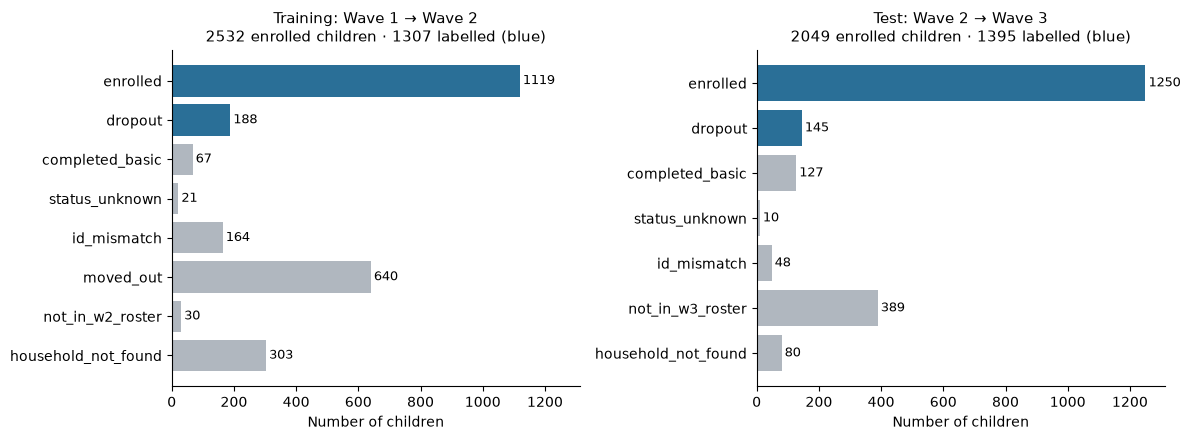

In [16]:
import matplotlib.pyplot as plt

order = ["enrolled", "dropout", "completed_basic", "status_unknown", "id_mismatch",
         "moved_out", "not_in_w2_roster", "not_in_w3_roster", "household_not_found"]
used = {"enrolled", "dropout"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
for ax, (df, title) in zip(axes, [(base, "Training: Wave 1 → Wave 2"), (base2, "Test: Wave 2 → Wave 3")]):
    counts = df["status"].value_counts().reindex([s for s in order if s in set(df["status"])])
    colors = ["#2a6f97" if s in used else "#b0b7bf" for s in counts.index]
    ax.barh(counts.index[::-1], counts.values[::-1], color=colors[::-1])
    for y, v in enumerate(counts.values[::-1]):
        ax.text(v + 10, y, str(v), va="center", fontsize=9)
    n_used = counts[counts.index.isin(used)].sum()
    ax.set_title(f"{title}\n{len(df)} enrolled children · {n_used} labelled (blue)", fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_xlabel("Number of children"); axes[1].set_xlabel("Number of children")
plt.tight_layout()
plt.savefig(ROOT / "figures" / "fig0_sample_flow.png", dpi=300, bbox_inches="tight")
plt.show()